In [1]:
from random import random

import numpy as np

import matplotlib.pyplot as plt
import networkx as nx

import matplotlib as mpl
import json
import copy

In [2]:

import sys
import logging
sys.path.append('E:\wangzhilin\QuantumGalaxy')
from QGI.mysql import MYSQL

import pandas as pd
import numpy as np
from QGI.neoapi import Neo4j
from QGI.feishu import *
import os
def get_logger(name,level=None,file=None):
    logger=logging.getLogger(name)
    logger.setLevel(logging.INFO)
    
    ch=logging.StreamHandler()
    ch.setLevel(logging.INFO)
    formatter=logging.Formatter(fmt='%(asctime)s %(name)-12s %(levelname)-8s %(message)s',datefmt='%m-%d %H:%M')
    ch.setFormatter(formatter)
    
    logger.addHandler(ch)
    if file:    
        fh=logging.FileHandler("E:/wangzhilin/QuantumGalaxy/logs/%s.log"%file,'a',encoding='utf-8')
        fh.setLevel(logging.INFO)
        fh.setFormatter(formatter)
        logger.addHandler(fh)
    return logger
logger=get_logger('logger')
uri = "neo4j+ssc://08ef0a79.databases.neo4j.io"
user = "QG_Editor"
password = "editor"
neo=Neo4j(uri,user,password)


In [3]:
import networkx

## 从neo找到骨干节点和边，从mysql找到相关节点的stdchg数据


In [4]:
backbone='煤炭'
cypher='match (n) where n.backbone contains "%s" \
return distinct n.name,labels(n),n.backbone,n.code \
union all \
match (n1) where n1.backbone contains "%s" \
with n1 \
match (n:Indicator)-[]-(n1) \
return  distinct n.name,labels(n),n.backbone,n.code order by labels(n)'%(backbone,backbone)
nodes=neo.read_query(cypher)
cypher='match p=(n1)-[r]->(n2) where n1.backbone contains "%s" and n2.backbone contains "%s" return startNode(r).name,endNode(r).name,type(r) \
union all \
match p=(n:Indicator)-[r]-(n1) where n1.backbone contains "%s"\
return  distinct startNode(r).name,endNode(r).name,type(r)'%(backbone,backbone,backbone)
edges=neo.read_query(cypher)

11-03 17:43 logger       INFO     accept cypher query match (n) where n.backbone contains "煤炭" return distinct n.name,labels(n),n.backbone,n.code union all match (n1) where n1.backbone contains "煤炭" with n1 match (n:Indicator)-[]-(n1) return  distinct n.name,labels(n),n.backbone,n.code order by labels(n)
11-03 17:43 logger       INFO     get 62 records
11-03 17:43 logger       INFO     accept cypher query match p=(n1)-[r]->(n2) where n1.backbone contains "煤炭" and n2.backbone contains "煤炭" return startNode(r).name,endNode(r).name,type(r) union all match p=(n:Indicator)-[r]-(n1) where n1.backbone contains "煤炭"return  distinct startNode(r).name,endNode(r).name,type(r)
11-03 17:43 logger       INFO     get 84 records


In [5]:
host='localhost'
user='Local_Editor'
password='QuantumGalaxy'
database='qgdbs'
mysql=MYSQL(host,user,password,database)

11-03 17:43 logger       INFO     using username Local_Editor
11-03 17:43 logger       INFO     accessed to database <qgdbs>


In [6]:
date=mysql.read_query('select date from processed_data where code="000001.SZ" order by date desc limit 1')
std7d=pd.DataFrame(index=[d[0] for d in date])
std1m=pd.DataFrame(index=[d[0] for d in date])
std3m=pd.DataFrame(index=[d[0] for d in date])

for node in nodes:
    code=node[3]
    if code:
        d=mysql.read_query('select date,stdchg7d,stdchg1m,stdchg3m from processed_data where code= "%s" order by date desc limit 30'%code)
        df7d=pd.DataFrame(index=[row[0]for row in d],columns=[code],data=[row[1] for row in d])
        df1m=pd.DataFrame(index=[row[0]for row in d],columns=[code],data=[row[2] for row in d])
        df3m=pd.DataFrame(index=[row[0]for row in d],columns=[code],data=[row[3] for row in d])
        std7d=pd.concat([std7d,df7d],axis=1)
        std1m=pd.concat([std1m,df1m],axis=1)
        std3m=pd.concat([std3m,df3m],axis=1)

11-03 17:43 logger       INFO     got a cursor
11-03 17:43 logger       INFO     Accepted read sql query "select date from processed_data where code="000001.SZ" order by date desc limit 1"
11-03 17:43 logger       INFO     got a cursor
11-03 17:43 logger       INFO     Accepted read sql query "select date,stdchg7d,stdchg1m,stdchg3m from processed_data where code= "600123.SH" order by date desc limit 30"
11-03 17:43 logger       INFO     got a cursor
11-03 17:43 logger       INFO     Accepted read sql query "select date,stdchg7d,stdchg1m,stdchg3m from processed_data where code= "3668.HK" order by date desc limit 30"
11-03 17:43 logger       INFO     got a cursor
11-03 17:43 logger       INFO     Accepted read sql query "select date,stdchg7d,stdchg1m,stdchg3m from processed_data where code= "AMR.N" order by date desc limit 30"
11-03 17:43 logger       INFO     got a cursor
11-03 17:43 logger       INFO     Accepted read sql query "select date,stdchg7d,stdchg1m,stdchg3m from processed_dat

In [7]:
std7d

,600123.SH,3668.HK,AMR.N,600546.SH,600188.SH,600746.SH,600426.SH,600010.SH,BTU.N,SSL.N,...,600027.SH,600780.SH,000557.SZ,600989.SH,600578.SH,600397.SH,ZC.CZC,JM.DCE,J.DCE,I.DCE
2022-11-03,-0.272786,-0.547317,NaN,-0.144969,-0.524856,-0.508446,0.210573,-0.542549,NaN,NaN,...,-1.085140,0.431569,0.038215,0.149971,-0.453052,-0.348488,None,0.215967,-0.317142,-0.265229
2022-11-02,0.162342,-0.487402,0.115681,0.486768,-0.308906,-0.531095,0.495478,-0.402612,-0.020612,-0.592593,...,-1.725180,0.968715,0.351003,-0.185272,-0.570053,-0.172547,None,0.027864,-0.525969,-0.967016
2022-11-01,0.020212,-1.286450,0.344633,0.303214,-1.426220,-0.634109,0.208318,0.000000,0.058514,-0.300891,...,-1.847570,1.559310,0.300645,-0.359097,-0.286351,-0.845632,None,-0.170405,-0.731260,-1.192450
2022-10-31,-0.297169,-0.930846,0.331190,-0.432341,-1.268850,-1.566540,-1.348150,-0.757183,0.074229,0.706519,...,-1.388460,1.065890,0.020140,-1.273180,-0.712930,-0.827746,None,-1.311350,-1.493990,-2.168760
2022-10-28,-0.280314,-0.791500,0.766276,-0.035355,-0.711430,-1.925130,-1.066060,-0.898215,0.491604,1.225440,...,-2.010320,0.959690,0.138158,-0.636651,-0.836143,-1.047670,None,-0.725857,-0.749771,-1.532240
2022-10-27,-0.625776,0.201886,0.973192,-0.423915,-0.559380,-0.821282,-0.953911,0.000000,0.170179,1.120500,...,-0.691633,0.450190,0.354292,0.024475,0.000000,-0.757573,None,-0.420884,-0.267790,-0.671610
2022-10-26,-1.319780,-0.335343,0.837057,-1.163870,-0.965510,-0.928093,-1.226200,0.460803,-0.802816,-0.428632,...,-0.698404,0.745288,-0.160248,-0.157731,0.176727,-1.271190,None,-0.571487,-0.666352,-0.698368
2022-10-25,-1.101220,-0.164244,0.401179,-0.815319,-0.632452,-1.474550,-1.620690,-1.174280,-0.999609,-0.740373,...,-0.789519,-0.282538,-0.284568,-0.881459,-0.397797,-1.285390,None,-0.478730,-0.452902,-0.472725
2022-10-24,-0.667464,-0.219650,0.516599,-0.273043,-0.592934,-1.395360,-0.452972,-1.547930,-0.695572,-0.182615,...,-0.515458,-0.353067,0.000000,-0.881471,-0.461452,-1.205980,None,-0.087657,-0.372607,-0.185447
2022-10-21,-0.566609,-0.106008,0.281579,-0.401014,-0.500017,-0.201210,-0.006753,-0.602564,-0.905175,-0.719717,...,-0.553805,-0.760091,0.460133,-0.412477,-0.371203,-0.682261,None,-0.883617,-1.293730,-0.681981


In [8]:
for col,ser in std1m.iteritems():
    for id,data in ser.iteritems():
        if data>2:
            print(id,col,data)
            std1m.loc[id,col]=2
        elif data<-2:
            print(id,col,data)
            std1m.loc[id,col]=-2
    

2022-10-14 AEP.O -2.24414
2022-10-13 AEP.O -2.26381
2022-10-12 AEP.O -2.76277
2022-10-11 AEP.O -2.3926
2022-10-10 AEP.O -2.45135
2022-10-07 AEP.O -2.65923
2022-10-06 AEP.O -2.10756


TypeError: '>' not supported between instances of 'NoneType' and 'int'

In [ ]:
std7d=std7d.sort_index().fillna(method='bfill').dropna()
std7d.to_csv(r'E:\wangzhilin\QuantumGalaxy\backbone\raw_data\std7d.csv')
std1m=std1m.sort_index().fillna(method='bfill').dropna()
std1m.to_csv(r'E:\wangzhilin\QuantumGalaxy\backbone\raw_data\std1m.csv')
std3m=std3m.sort_index().fillna(method='bfill').dropna()
std3m.to_csv(r'E:\wangzhilin\QuantumGalaxy\backbone\raw_data\std3m.csv')
std1m

,600123.SH,3668.HK,AMR.N,600546.SH,600188.SH,600746.SH,600426.SH,600010.SH,BTU.N,SSL.N,...,VALE.N,600027.SH,600780.SH,000557.SZ,600989.SH,600578.SH,ZC.CZC,JM.DCE,J.DCE,I.DCE
2022-07-29,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,-0.041727,-0.540828,...,-0.301002,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-01,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,-0.041727,-0.252832,...,-0.301002,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-02,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,-0.041727,-0.488067,...,-0.301002,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-05,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,-0.041727,-0.106502,...,-0.301002,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-08,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,-0.041727,-0.420089,...,-0.301002,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-09,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,-0.041727,-0.375507,...,-0.301002,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-10,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,0.142801,-0.039824,...,0.127922,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-11,0.135646,-0.096908,0.781054,0.806269,1.091870,0.393870,0.675844,0.279668,0.328563,0.449430,...,0.312809,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-12,0.135646,-0.096908,0.746568,0.806269,1.091870,0.393870,0.675844,0.279668,0.337244,0.449430,...,0.070676,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709
2022-08-15,0.135646,-0.096908,0.618012,0.806269,1.091870,0.393870,0.675844,0.279668,0.389954,0.605396,...,0.403134,0.245029,0.341581,-0.269411,0.636266,0.543607,0.302366,0.479677,0.794196,0.490709


In [9]:
node[1]

['Indicator']

## 获得初始graph实例，以及画networkx图轮子

In [12]:
class QGDiGraph(nx.DiGraph):
    pass
def init_graph():
    G=QGDiGraph()
    assert nx.is_directed_acyclic_graph(G)
    
    for node in nodes:
        G.add_node(node[0],**node[1:])
    for edge in edges:
        G.add_edge(edge[0],edge[1],relationship=edge[2])
    return G
G=init_graph()

In [13]:
for a in nx.ancestors(G,'热力'):
    print(G.nodes[a]['labels(n)'])

['Company', 'Indicator']
['Company', 'Indicator']
['Technique']
['Product']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Technique']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Product']
['Company', 'Indicator']
['Company', 'Indicator']
['Product']
['Indicator']
['Company', 'Indicator']
['Product']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Product']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']
['Company', 'Indicator']


In [14]:
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"]=["SimHei"] #设置字体
plt.rcParams["axes.unicode_minus"]=False #该语句解决图像中的“-”负号的乱码问题

In [15]:
class Backbone_handler():
    def __init__(self,G:nx.Graph):
        self.G=G

    def nodes_group_by_label(self):
        G=self.G
        self.product={}
        self.company={}
        self.technique={}
        self.nodes={'product':self.product,'company':self.company,'technique':self.technique}
        for node,attr in G.nodes(True):
            labels=attr['labels(n)']
            if 'Product' in labels:
                self.product[node]=attr
            elif 'Company' in labels:
                self.company[node]=attr
            elif 'Technique' in labels:
                self.technique[node]=attr
        
    def edges_group_by_rela(self):
        G=self.G
        self.carry=[]
        self.compose=[]
        self.edges={'compose':self.compose,'carry':self.carry}
        for s,e,attr in G.edges(data=True):
            rela=attr['relationship']
            attr['velocity']=random()
            if 'compose' in rela:
                self.compose.append((s,e,attr))
            if 'carry' in rela:
                self.carry.append((s,e,attr))

    def draw_graph(self,frame=0):
        cmap=plt.cm.winter_r
        self.nodes_group_by_label()
        self.edges_group_by_rela()
        #pos=nx.spring_layout(G,k=1/sqrt(len(self.G.nodes)),weight=None,scale=1,seed=20)
        pos=nx.spring_layout(self.G,k=1e4/self.G.number_of_nodes(),scale=1,seed=1,iterations=10000,threshold=1e-15)
        #pos: dict for every nodes with 2d ndarray [0.999999988, 1.33118354e-08]
        #pos['合成氨']=[9.99999988e-01, 1.33118354e-08]
        fig, ax = plt.subplots(dpi=200)
        for label,nodes in self.nodes.items():
            if label=='product':
                draw_args={'nodelist':nodes,'node_size':250,'node_color':"#1f78b4",'node_shape':"o",}
            #print(draw_args)
            elif label=='technique':
                draw_args={'nodelist':nodes,'node_size':250,'node_color':"#1f78b4",'node_shape':"v",}
            nx.draw_networkx_nodes(G, pos=pos,ax=ax, **draw_args)

        # edges
        
        edge_colors=[]
        for rela,edges in self.edges.items():
                
            e = [(u, v) for (u, v, d) in edges ]
            colors=[d['velocity'] for (u, v, d) in edges ]
            draw_args={'width':6,'edge_color':"k",'style':"solid",'alpha':None,'arrowstyle':"-|>",'arrowsize':10,'label':None,'edge_color':colors,'edge_cmap':cmap}
            draw_edges=nx.draw_networkx_edges(G, pos, edgelist=e, ax=ax,**draw_args)
            edge_colors+=colors
        #edge_colors=[d['velocity'] for (u, v, d) in G.edges(data=True) ]
        
        # node labels
        nx.draw_networkx_labels(G, pos, font_size=10, font_family="sans-serif",ax=ax)
        # edge weight labels
        edge_labels = nx.get_edge_attributes(G, "velocity")
        edge_labels={k:round(v,2) for k,v in edge_labels.items()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels,ax=ax)

        ax = plt.gca()
        ax.margins(0.1)
        plt.axis("off")
        plt.tight_layout()
        pc = mpl.collections.PatchCollection(draw_edges, cmap=cmap)
        pc.set_array(edge_colors)

        ax = plt.gca()
        ax.set_axis_off()
        plt.colorbar(pc,ax=ax)
        plt.show()
        #return(draw_edges)
    def export_json(self):
        pass


In [16]:
a=Backbone_handler(G)


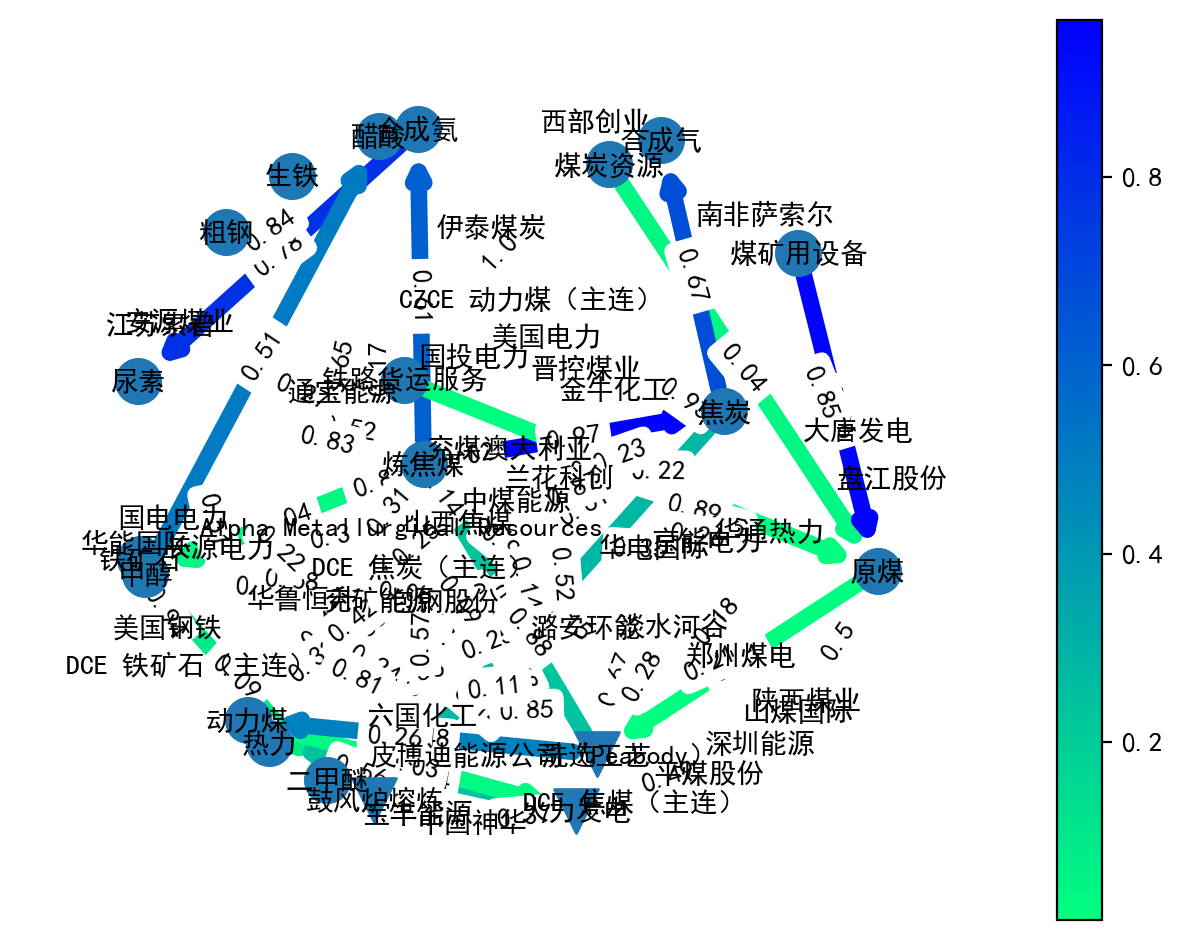

In [17]:

e=a.draw_graph()

In [18]:
G.number_of_nodes()

62

In [19]:
G.__class__

__main__.QGDiGraph

## 影响力传导计算
1. 从所有indicator边传导到对应的产品/工艺的供需差（数据用stdchg1m），在各节点加权平均（权重暂为1，考虑用市值/量利等），得到多个在节点上的初始激励
2. 使用定好的算法计算每个激励在图上的传播，并加和得到节点的供需差和边上的供需差强度变化(ds_current)。（该计算可以通过生成网络的影响力矩阵获得，影响力矩阵是由网络结构得到的网络中任何一个点/边之间的影响力参数）

### step1

In [20]:
raw_data=std1m.iloc[ 0:1,:]
raw_data

,600123.SH,3668.HK,AMR.N,600546.SH,600188.SH,600746.SH,600426.SH,600010.SH,BTU.N,SSL.N,...,600027.SH,600780.SH,000557.SZ,600989.SH,600578.SH,600397.SH,ZC.CZC,JM.DCE,J.DCE,I.DCE
2022-11-03,-0.803336,-0.658044,NaN,-0.718575,-1.13434,-0.322037,-0.464623,-0.13175,NaN,NaN,...,-0.769204,1.16441,0.423234,-0.217681,0.250642,-0.537335,None,-0.429732,-0.963965,-1.16882


In [21]:
G.successors()

TypeError: successors() missing 1 required positional argument: 'n'

In [22]:
'688083.SH'.lower()

'688083.sh'

In [23]:
G.nodes

NodeView(('合成氨', '甲醇', '二甲醚', '热力', '鼓风炉熔炼', '煤炭资源', '醋酸', '尿素', '火力发电', '动力煤', '煤矿用设备', '粗钢', '焦炭', '炼焦煤', '生铁', '铁矿石', '原煤', '洗选工艺', '合成气', '铁路货运服务', '兰花科创', '兖煤澳大利亚', 'Alpha Metallurgical Resources', '山煤国际', '兖矿能源', '江苏索普', '华鲁恒升', '包钢股份', '皮博迪能源公司（Peabody）', '南非萨索尔', '美国钢铁', '陕西煤业', '长源电力', '潞安环能', '盘江股份', '平煤股份', '山西焦煤', '中国神华', '中煤能源', '晋控煤业', '大唐发电', '深圳能源', '国投电力', '美国电力', '华通热力', '伊泰煤炭', '金牛化工', '六国化工', '郑州煤电', '国电电力', '华能国际', '淡水河谷', '华电国际', '通宝能源', '西部创业', '宝丰能源', '京能电力', '安源煤业', 'CZCE 动力煤（主连）', 'DCE 焦煤（主连）', 'DCE 焦炭（主连）', 'DCE 铁矿石（主连）'))

In [24]:
for s  in G.successors('醋酸'):
    print(s)

In [35]:
G=init_graph()

dic={}
for name,attr in G.nodes(True):
    if attr['n.code']:
        dic[attr['n.code']]=name
for date,r in std1m.iterrows():
    G=init_graph()
    #每天为一组数据，放到nodes/edges里
    #print(date)
    datas=r.values
    column=r.index
    #print(r)
    for code,data in r.iteritems():
        node=dic[code]
        print(node,data)
        G.nodes[node]['std']=data
    

兰花科创 -0.803336
兖煤澳大利亚 -0.658044
Alpha Metallurgical Resources nan
山煤国际 -0.718575
兖矿能源 -1.13434
江苏索普 -0.322037
华鲁恒升 -0.464623
包钢股份 -0.13175
皮博迪能源公司（Peabody） nan
南非萨索尔 nan
美国钢铁 nan
陕西煤业 -0.925538
长源电力 0.266805
潞安环能 -0.323664
盘江股份 -1.61541
平煤股份 -1.2267
山西焦煤 -1.56984
中国神华 -0.831715
中煤能源 -1.1467
晋控煤业 -1.46127
大唐发电 -1.03727
深圳能源 0.347663
国投电力 -0.750264
美国电力 nan
华通热力 -0.0565751
伊泰煤炭 -0.302359
金牛化工 0.0
六国化工 -0.581769
郑州煤电 -0.243864
国电电力 0.356746
华能国际 -0.713558
淡水河谷 nan
华电国际 -0.769204
通宝能源 1.16441
西部创业 0.423234
宝丰能源 -0.217681
京能电力 0.250642
安源煤业 -0.537335
CZCE 动力煤（主连） None
DCE 焦煤（主连） -0.429732
DCE 焦炭（主连） -0.963965
DCE 铁矿石（主连） -1.16882
兰花科创 -0.725196
兖煤澳大利亚 -0.640667
Alpha Metallurgical Resources 0.761033
山煤国际 -0.61816
兖矿能源 -1.07776
江苏索普 -0.328693
华鲁恒升 -0.435935
包钢股份 0.131404
皮博迪能源公司（Peabody） -0.36492
南非萨索尔 -0.295418
美国钢铁 0.281735
陕西煤业 -0.872196
长源电力 0.302154
潞安环能 -0.297174
盘江股份 -1.52147
平煤股份 -1.24293
山西焦煤 -1.49231
中国神华 -0.734789
中煤能源 -1.14391
晋控煤业 -1.31167
大唐发电 -0.880473
深圳能源 0.4131
国投电力 -0.7796

In [34]:
G.nodes('std')

NodeDataView({'合成氨': None, '甲醇': None, '二甲醚': None, '热力': None, '鼓风炉熔炼': None, '煤炭资源': None, '醋酸': None, '尿素': None, '火力发电': None, '动力煤': None, '煤矿用设备': None, '粗钢': None, '焦炭': None, '炼焦煤': None, '生铁': None, '铁矿石': None, '原煤': None, '洗选工艺': None, '合成气': None, '铁路货运服务': None, '兰花科创': nan, '兖煤澳大利亚': nan, 'Alpha Metallurgical Resources': 0.0534697, '山煤国际': nan, '兖矿能源': nan, '江苏索普': nan, '华鲁恒升': nan, '包钢股份': nan, '皮博迪能源公司（Peabody）': 0.484809, '南非萨索尔': -0.430592, '美国钢铁': -0.454355, '陕西煤业': nan, '长源电力': nan, '潞安环能': nan, '盘江股份': nan, '平煤股份': nan, '山西焦煤': nan, '中国神华': nan, '中煤能源': nan, '晋控煤业': nan, '大唐发电': nan, '深圳能源': nan, '国投电力': nan, '美国电力': -1.51335, '华通热力': nan, '伊泰煤炭': nan, '金牛化工': nan, '六国化工': nan, '郑州煤电': nan, '国电电力': nan, '华能国际': nan, '淡水河谷': 1.01956, '华电国际': nan, '通宝能源': nan, '西部创业': nan, '宝丰能源': nan, '京能电力': nan, '安源煤业': nan, 'CZCE 动力煤（主连）': None, 'DCE 焦煤（主连）': nan, 'DCE 焦炭（主连）': nan, 'DCE 铁矿石（主连）': nan}, data='std')

In [36]:
dic

{'600123.SH': '兰花科创',
 '3668.HK': '兖煤澳大利亚',
 'AMR.N': 'Alpha Metallurgical Resources',
 '600546.SH': '山煤国际',
 '600188.SH': '兖矿能源',
 '600746.SH': '江苏索普',
 '600426.SH': '华鲁恒升',
 '600010.SH': '包钢股份',
 'BTU.N': '皮博迪能源公司（Peabody）',
 'SSL.N': '南非萨索尔',
 'X.N': '美国钢铁',
 '601225.SH': '陕西煤业',
 '000966.SZ': '长源电力',
 '601699.SH': '潞安环能',
 '600395.SH': '盘江股份',
 '601666.SH': '平煤股份',
 '000983.SZ': '山西焦煤',
 '601088.SH': '中国神华',
 '601898.SH': '中煤能源',
 '601001.SH': '晋控煤业',
 '601991.SH': '大唐发电',
 '000027.SZ': '深圳能源',
 '600886.SH': '国投电力',
 'AEP.O': '美国电力',
 '002893.SZ': '华通热力',
 '3948.HK': '伊泰煤炭',
 '600722.SH': '金牛化工',
 '600470.SH': '六国化工',
 '600121.SH': '郑州煤电',
 '600795.SH': '国电电力',
 '600011.SH': '华能国际',
 'VALE.N': '淡水河谷',
 '600027.SH': '华电国际',
 '600780.SH': '通宝能源',
 '000557.SZ': '西部创业',
 '600989.SH': '宝丰能源',
 '600578.SH': '京能电力',
 '600397.SH': '安源煤业',
 'ZC.CZC': 'CZCE 动力煤（主连）',
 'JM.DCE': 'DCE 焦煤（主连）',
 'J.DCE': 'DCE 焦炭（主连）',
 'I.DCE': 'DCE 铁矿石（主连）'}

In [37]:
G.nodes.data('i')

NodeDataView({'合成氨': None, '甲醇': None, '二甲醚': None, '热力': None, '鼓风炉熔炼': None, '煤炭资源': None, '醋酸': None, '尿素': None, '火力发电': None, '动力煤': None, '煤矿用设备': None, '粗钢': None, '焦炭': None, '炼焦煤': None, '生铁': None, '铁矿石': None, '原煤': None, '洗选工艺': None, '合成气': None, '铁路货运服务': None, '兰花科创': None, '兖煤澳大利亚': None, 'Alpha Metallurgical Resources': None, '山煤国际': None, '兖矿能源': None, '江苏索普': None, '华鲁恒升': None, '包钢股份': None, '皮博迪能源公司（Peabody）': None, '南非萨索尔': None, '美国钢铁': None, '陕西煤业': None, '长源电力': None, '潞安环能': None, '盘江股份': None, '平煤股份': None, '山西焦煤': None, '中国神华': None, '中煤能源': None, '晋控煤业': None, '大唐发电': None, '深圳能源': None, '国投电力': None, '美国电力': None, '华通热力': None, '伊泰煤炭': None, '金牛化工': None, '六国化工': None, '郑州煤电': None, '国电电力': None, '华能国际': None, '淡水河谷': None, '华电国际': None, '通宝能源': None, '西部创业': None, '宝丰能源': None, '京能电力': None, '安源煤业': None, 'CZCE 动力煤（主连）': None, 'DCE 焦煤（主连）': None, 'DCE 焦炭（主连）': None, 'DCE 铁矿石（主连）': None}, data='i')

In [38]:
for n,preds in G.pred.items():
    if preds:
        values=[]
        for pred in preds:
            std=G.nodes.data('std')[pred]
            
            if std:
                values.append(std)
        if len(values)!=0:
            G.nodes[n]['i']=np.average(values)
[(n,d) for (n,d) in G.nodes.data('i') if d]

[('甲醇', nan),
 ('二甲醚', nan),
 ('热力', nan),
 ('醋酸', nan),
 ('尿素', nan),
 ('火力发电', nan),
 ('动力煤', nan),
 ('焦炭', nan),
 ('炼焦煤', nan),
 ('铁矿石', nan),
 ('原煤', nan),
 ('铁路货运服务', nan)]

### step 2


In [39]:
dir(G)

['__class__',
 '__contains__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_adj',
 '_node',
 '_pred',
 '_succ',
 'add_edge',
 'add_edges_from',
 'add_node',
 'add_nodes_from',
 'add_weighted_edges_from',
 'adj',
 'adjacency',
 'adjlist_inner_dict_factory',
 'adjlist_outer_dict_factory',
 'clear',
 'clear_edges',
 'copy',
 'degree',
 'edge_attr_dict_factory',
 'edge_subgraph',
 'edges',
 'get_edge_data',
 'graph',
 'graph_attr_dict_factory',
 'has_edge',
 'has_node',
 'has_predecessor',
 'has_successor',
 'in_degree',
 'in_edges',
 'is_directed',
 'is_multigraph',
 'name',
 'nbunch_iter',
 'neighbors',
 'node_attr_dict_factory',
 'node_di

## 从数据处理成颜色，将每帧数据保存到js文件

In [40]:
import copy

node_json=[]
for n in copy.deepcopy(G.nodes(data=True)):
    name,attr=n
    attr['name']=name
    attr['labels']=attr.pop('labels(n)')
    node_json.append(attr)
edge_json=[]
for e in copy.deepcopy(G.edges(data=True)):
    s,end,attr=e
    attr['source']=s
    attr['target']=end
    
    edge_json.append(attr)
#node_json=json.dumps(node_json)
#edge_json=json.dumps(edge_json)
data=json.dumps({'nodes':node_json,'links':edge_json,'categories':['Product','Technique','Company','Indicator']},ensure_ascii=False)
data

'{"nodes": [{"n.backbone": "石油天然气,煤炭", "n.code": null, "name": "合成氨", "labels": ["Product"]}, {"n.backbone": "煤炭", "n.code": null, "i": NaN, "name": "甲醇", "labels": ["Product"]}, {"n.backbone": "煤炭", "n.code": null, "i": NaN, "name": "二甲醚", "labels": ["Product"]}, {"n.backbone": "煤炭", "n.code": null, "i": NaN, "name": "热力", "labels": ["Product"]}, {"n.backbone": "煤炭", "n.code": null, "name": "鼓风炉熔炼", "labels": ["Technique"]}, {"n.backbone": "煤炭", "n.code": null, "name": "煤炭资源", "labels": ["Product"]}, {"n.backbone": "煤炭", "n.code": null, "i": NaN, "name": "醋酸", "labels": ["Product"]}, {"n.backbone": "煤炭", "n.code": null, "i": NaN, "name": "尿素", "labels": ["Product"]}, {"n.backbone": "电力,煤炭", "n.code": null, "i": NaN, "name": "火力发电", "labels": ["Technique"]}, {"n.backbone": "电力,煤炭", "n.code": null, "i": NaN, "name": "动力煤", "labels": ["Product"]}, {"n.backbone": "煤炭", "n.code": null, "name": "煤矿用设备", "labels": ["Product"]}, {"n.backbone": "钢铁,煤炭", "n.code": null, "name": "粗钢", "labels": 

In [42]:
nx.is_directed_acyclic_graph(G)

True

In [43]:
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import cool

In [44]:
cdict = {'red':   [[0.0,  91/255, 91/255],
                   [0.5,  200/255, 200/255],
                   [1.0,  255/255, 255/255]],
         'green': [[0.0,  218/255, 218/255],
                   [0.5, 200/255, 200/255],
                   [1, 94/255, 94/255]],

         'blue':  [[0.0,  146/255, 146/255],
                   [0.5,  121.5/255, 121.5/255],
                   [1.0,  97/255, 97/255]]}

cdict = {'red':   [[0.0,  121/255, 121/255],
                   
                   [1.0,  241/255, 241/255]],
         'green': [[0.0,  240/255, 240/255],
                   
                   [1, 70/255, 70/255]],

         'blue':  [[0.0,  120/255, 120/255],
                   
                   [1.0,  103/255, 103/255]]}
regrcmp = LinearSegmentedColormap('testCmap', segmentdata=cdict, N=256)
rgba = regrcmp(np.linspace(0, 1, 256))

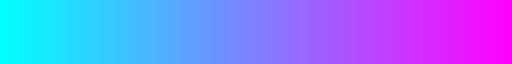

In [45]:
from matplotlib.cm import cool
cool

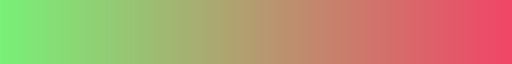

In [46]:
regrcmp

In [47]:
datas=[0,1,2,3,4,5,6,7,8,9,10]
def normalize(data,datas):

    return (data-np.min(datas))/(np.max(datas)-np.min(datas))
d=normalize(10,datas)
d

1.0

In [48]:
coolcmp=cool


In [49]:
def get_cmap_color_str(data,cmap):
    '''从正则后的颜色值，获取指定cmap中的颜色，并转化为echarts需要的“rgba(255,255,255,1)”形式'''
    c=cmap(data)
    colors=(c[0]*255,c[1]*255,c[2]*255,1)
    return(f'rgba{colors}')

In [50]:
get_cmap_color_str(0.05,cool)

'rgba(12.0, 243.0, 255.0, 1)'

In [51]:
for n in copy.deepcopy(G.nodes(data=True)):
    n[1]['color']='asdf'
    print(n)

('合成氨', {'labels(n)': ['Product'], 'n.backbone': '石油天然气,煤炭', 'n.code': None, 'color': 'asdf'})
('甲醇', {'labels(n)': ['Product'], 'n.backbone': '煤炭', 'n.code': None, 'color': 'asdf'})
('二甲醚', {'labels(n)': ['Product'], 'n.backbone': '煤炭', 'n.code': None, 'color': 'asdf'})
('热力', {'labels(n)': ['Product'], 'n.backbone': '煤炭', 'n.code': None, 'color': 'asdf'})
('鼓风炉熔炼', {'labels(n)': ['Technique'], 'n.backbone': '煤炭', 'n.code': None, 'color': 'asdf'})
('煤炭资源', {'labels(n)': ['Product'], 'n.backbone': '煤炭', 'n.code': None, 'color': 'asdf'})
('醋酸', {'labels(n)': ['Product'], 'n.backbone': '煤炭', 'n.code': None, 'color': 'asdf'})
('尿素', {'labels(n)': ['Product'], 'n.backbone': '煤炭', 'n.code': None, 'color': 'asdf'})
('火力发电', {'labels(n)': ['Technique'], 'n.backbone': '电力,煤炭', 'n.code': None, 'color': 'asdf'})
('动力煤', {'labels(n)': ['Product'], 'n.backbone': '电力,煤炭', 'n.code': None, 'color': 'asdf'})
('煤矿用设备', {'labels(n)': ['Product'], 'n.backbone': '煤炭', 'n.code': None, 'color': 'asdf'})
('粗

In [52]:
G.number_of_nodes()

62

In [53]:
import pandas as pd
df=pd.DataFrame([[1,2,3],[4,5,6]])
df

,0,1,2
0,1,2,3
1,4,5,6


In [54]:
last_r=df.iloc[-1:]

In [17]:
last_r.index+=1
last_r

,0,1,2
2,4,5,6


In [10]:
df.loc[1,:]

0    4
1    5
2    6
Name: 1, dtype: int64

In [ ]:
nodes

In [55]:
jsdata={}
jsdata['categories']=[{'name':"Product"},{'name':"Technique"}, {'name':"Company"}, {'name':"Indicator"}]
jsdata['dates']=std1m.index.astype(str).tolist()
jsdata['nodes']=[]
jsdata['links']=[]
jsdata

{'categories': [{'name': 'Product'},
  {'name': 'Technique'},
  {'name': 'Company'},
  {'name': 'Indicator'}],
 'dates': ['2022-11-03',
  '2022-11-02',
  '2022-11-01',
  '2022-10-31',
  '2022-10-28',
  '2022-10-27',
  '2022-10-26',
  '2022-10-25',
  '2022-10-24',
  '2022-10-21',
  '2022-10-20',
  '2022-10-19',
  '2022-10-18',
  '2022-10-17',
  '2022-10-14',
  '2022-10-13',
  '2022-10-12',
  '2022-10-11',
  '2022-10-10',
  '2022-10-07',
  '2022-10-06',
  '2022-10-05',
  '2022-10-03',
  '2022-09-30',
  '2022-09-29',
  '2022-09-28',
  '2022-09-27',
  '2022-09-26',
  '2022-09-23',
  '2022-09-22',
  '2022-10-04'],
 'nodes': [],
 'links': []}

In [59]:


dic={}
for name,attr in G.nodes(True):
    if attr['n.code']:
        dic[attr['n.code']]=name
for date,r in std1m.iterrows():
    G=init_graph()
    #每天为一组数据，放到nodes/edges里
    #print(date)
    datas=r.values
    column=r.index
    for code,data in r.iteritems():
        node=dic[code]
        G.nodes[node]['std']=data

        #nor=normalize(data,datas)
        #colorstr=get_cmap_color_str(nor,regrcmp)
        
        #print(colorstr)
    for u,v,attr in G.edges(data=True):
        if 'Indicator' in  G.nodes[u]['labels(n)'] :
            if 'measure' in attr['relationship'] or 'produce' in attr['relationship']:
                attr['velocity']=G.nodes[u]['std']
                print(attr['velocity'],datas)
                nor=normalize(attr['velocity'],datas)
                colorstr=get_cmap_color_str(nor,regrcmp)
                attr['color']=colorstr
        else:
            attr['velocity']=0
        #a=Backbone_handler(G)


        node_json=[]
        stock=list(nx.get_node_attributes(G,'std').values())
        for n in copy.deepcopy(G.nodes(data=True)):
            name,attr=n
            attr['name']=name
            attr['labels']=attr.pop('labels(n)')
            #attr['color']=get_cmap_color_str(normalize(attr['stock'],stock),regrcmp)
            node_json.append(attr)
            
        edge_json=[]
        velocity=list(nx.get_edge_attributes(G,'velocity').values())

        for e in copy.deepcopy(G.edges(data=True)):
            s,end,attr=e
            attr['source']=s
            attr['target']=end
            #print(attr)
            #attr['color']=get_cmap_color_str(normalize(attr['velocity'],velocity),regrcmp)
            #attr['color']=
            #
            edge_json.append(attr)
        #print(edge_json)
        
    #node_json=json.dumps(node_json)
    #edge_json=json.dumps(edge_json)
    jsdata['nodes'].append(node_json)
    jsdata['links'].append(edge_json)
    
jsdata

-0.803336 [-0.803336 -0.658044 nan -0.718575 -1.13434 -0.322037 -0.464623 -0.13175
 nan nan nan -0.925538 0.266805 -0.323664 -1.61541 -1.2267 -1.56984
 -0.831715 -1.1467 -1.46127 -1.03727 0.347663 -0.750264 nan -0.0565751
 -0.302359 0.0 -0.581769 -0.243864 0.356746 -0.713558 nan -0.769204
 1.16441 0.423234 -0.217681 0.250642 -0.537335 None -0.429732 -0.963965
 -1.16882]


TypeError: '<=' not supported between instances of 'float' and 'NoneType'

In [60]:
std1m

,600123.SH,3668.HK,AMR.N,600546.SH,600188.SH,600746.SH,600426.SH,600010.SH,BTU.N,SSL.N,...,600027.SH,600780.SH,000557.SZ,600989.SH,600578.SH,600397.SH,ZC.CZC,JM.DCE,J.DCE,I.DCE
2022-11-03,-0.803336,-0.658044,NaN,-0.718575,-1.134340,-0.322037,-0.464623,-0.131750,NaN,NaN,...,-0.769204,1.164410,0.423234,-0.217681,0.250642,-0.537335,None,-0.429732,-0.963965,-1.168820
2022-11-02,-0.725196,-0.640667,0.761033,-0.618160,-1.077760,-0.328693,-0.435935,0.131404,-0.364920,-0.295418,...,-0.802771,1.452490,0.385165,-0.371084,0.383665,-0.420521,None,-0.471796,-0.987994,-1.235100
2022-11-01,-0.760718,-0.782033,0.977634,-0.551687,-1.393590,-0.378493,-0.406196,-0.135886,-0.149558,0.006415,...,-0.696679,1.389490,0.254549,-0.588425,0.381932,-0.649628,None,-0.536963,-1.052140,-1.249320
2022-10-31,-0.750875,-0.636465,0.942360,-0.658677,-1.303010,-0.731911,-1.020780,-0.580388,-0.138639,0.549394,...,-0.426426,1.171150,0.168088,-1.049890,0.214640,-0.757679,None,-0.817124,-1.302110,-1.600440
2022-10-28,-0.130936,-0.199438,0.966061,-0.319697,-0.826913,-0.856456,-0.218637,-0.362552,0.376707,0.323681,...,-0.700320,0.926147,0.193138,-0.359485,0.313362,-0.649528,None,-0.564997,-0.882808,-1.206940
2022-10-27,-0.275773,-0.135000,1.323870,-0.493584,-0.829579,-0.596872,-0.419256,-0.365654,0.222000,0.299752,...,-0.562748,0.569286,0.028113,-0.221173,0.197178,-0.414103,None,-0.610519,-0.795855,-0.997130
2022-10-26,-0.468525,-0.054788,1.561820,-0.828301,-0.945323,-0.368045,-0.496211,-0.146438,0.652549,0.255977,...,-0.329589,0.599782,0.019543,-0.356631,0.370182,-0.151419,None,-0.384836,-0.483479,-0.624774
2022-10-25,-0.711295,-0.748020,1.398300,-0.942678,-0.800173,-0.816184,-0.482741,-1.113830,0.688056,-0.036837,...,-0.104037,0.000000,-0.185637,-0.891725,0.087111,-0.246717,None,-0.366445,-0.490653,-0.631245
2022-10-24,-0.571681,-0.774387,1.398320,-0.719293,-0.800447,-0.650224,-0.308739,-1.107020,0.688035,0.009891,...,-0.055535,0.021642,-0.133015,-0.891738,0.124755,-0.353601,None,-0.095270,-0.365103,-0.493864
2022-10-21,-0.316100,-0.437486,0.767069,-0.435073,-0.762336,-0.822059,-0.323913,-0.924056,0.289579,-0.693264,...,-0.131715,-0.117685,-0.139629,-1.012080,0.142804,-0.190647,None,-0.082017,-0.347428,-0.341854


In [ ]:
js=json.dumps(jsdata,ensure_ascii=False)
js='graph='+js

file=open(r'E:\wangzhilin\QuantumGalaxy\server\static\full_data.js','w',encoding='UTF-8')
file.write(js)
file.close()

In [63]:
data=[1,2,3]
data+=[data[-1]]*10
data

[1, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3]

In [ ]:
std1m.index

In [ ]:
'''
data={}
data['categories']=[{'name':"Product"},{'name':"Technique"}, {'name':"Company"}, {'name':"Indicator"}]
data['dates']=std1m.index
data['nodes']=[]
data['links']=[]

for frame in range(100):
    print(frame)
    if frame==0:
        G=init_graph()
        
        num=0
        for u,v in nx.edge_dfs(G):
            d=G.edges[u,v]
            if d['relationship']==['compose','measure']:
                
                G.edges[u,v]['velocity']=np.sin(G.edges[u,v]['angle'])
                
                num+=1
                
            else:
                G.edges[u,v]['velocity']=0
        for n,d in G.nodes(data=True):
            if 'Product' in d['labels(n)']:
                G.nodes[n]['stock']=0
            else:
                G.nodes[n]['stock']=0
    else:
        for u,v,d in G.edges(data=True):
            if d['relationship'] in ['produce','measure']:
                G.edges[u,v]['angle']+=pi/9
                G.edges[u,v]['velocity']=np.sin(G.edges[u,v]['angle'])
            else:
                G.edges[u,v]['velocity']=0
        for n,d in G.nodes(data=True):
            if 'Product' in d['labels(n)']:
                G.nodes[n]['stock']+=0
                G.nodes[n]['stock']%=100
            else:
                G.nodes[n]['stock']=0

    #a=Backbone_handler(G)
    node_json=[]
    stock=list(nx.get_node_attributes(G,'stock').values())
    for n in copy.deepcopy(G.nodes(data=True)):
        name,attr=n
        attr['name']=name
        attr['labels']=attr.pop('labels(n)')
        attr['color']=get_cmap_color_str(normalize(attr['stock'],stock),regrcmp)
        node_json.append(attr)
        
    edge_json=[]
    velocity=list(nx.get_edge_attributes(G,'velocity').values())

    for e in copy.deepcopy(G.edges(data=True)):
        s,end,attr=e
        attr['source']=s
        attr['target']=end
        #print(attr)
        attr['color']=get_cmap_color_str(normalize(attr['velocity'],velocity),regrcmp)
        #attr['color']=
        #
        edge_json.append(attr)
    #node_json=json.dumps(node_json)
    #edge_json=json.dumps(edge_json)
    data['nodes'].append(node_json)
    data['links'].append(edge_json)
    
    
js=json.dumps(data,ensure_ascii=False)
js='data='+js
#按帧数生成frame个nodes和links json对象，每个对象里有当帧的点/边信息

data'''

In [ ]:
i=0
for u,v in nx.edge_dfs(G):
    print(u,v)
    i+=1
i

In [ ]:
G.number_of_edges()

In [ ]:
G.nodes['合成氨']['stock']+=15
G.nodes['合成氨']['stock']

In [ ]:
data['nodes'][0][0]

In [ ]:
for n in data['nodes']:
    print(n[0]['stock'])

In [ ]:

file=open(r'E:\wangzhilin\QuantumGalaxy\server\static\full_data.js','w',encoding='UTF-8')
file.write(js)
file.close()

In [ ]:
for e in copy.deepcopy(G.edges(data=True)):
    s,end,attr=e
    

In [ ]:
values=nx.get_edge_attributes(G,'velocity').values()
list(values)

In [ ]:
(2.27**(64-22))/60/60/24/365*1.65

In [ ]:
(2.27**(64-22))/60/60/24/365